In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load the diabetes dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target)

In [3]:
# Display the first 5 rows of the features (X)
print("Features (X):")
display(X.head())

# Display the first 5 rows of the target (y)
print("\nTarget (y):")
display(y.head())

Features (X):


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Target (y):


,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [4]:
# Transform the continuous target 'y' into a binary classification target
# We'll use the median as a threshold to create two classes: 0 (low progression) and 1 (high progression)
median_y = y.median()
y_binary = (y > median_y).astype(int)

print("Original target (y) description:")
print(y.describe())
print("\nBinary target (y_binary) value counts:")
print(y_binary.value_counts())

# Update the target to the binary version for subsequent steps
y = y_binary

Original target (y) description:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
dtype: float64

Binary target (y_binary) value counts:
1    221
0    221
Name: count, dtype: int64



Missing values in features (X):
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Missing values in target (y_binary):
0

Descriptive statistics for features (X):


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01



Visualizing feature distributions...


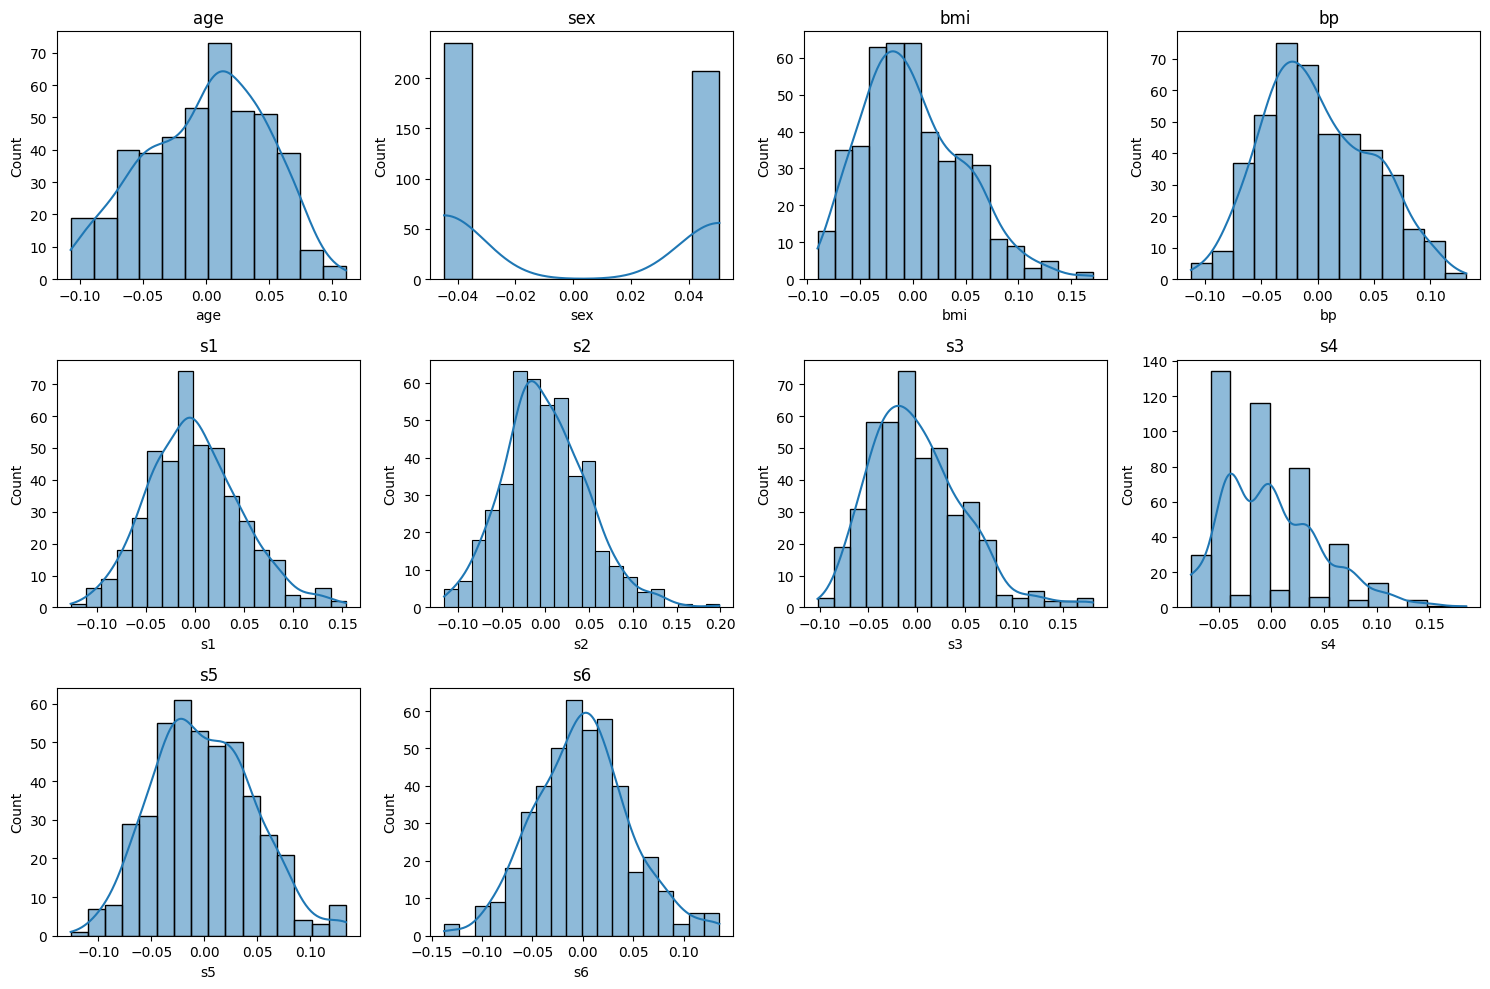


Visualizing correlation matrix...


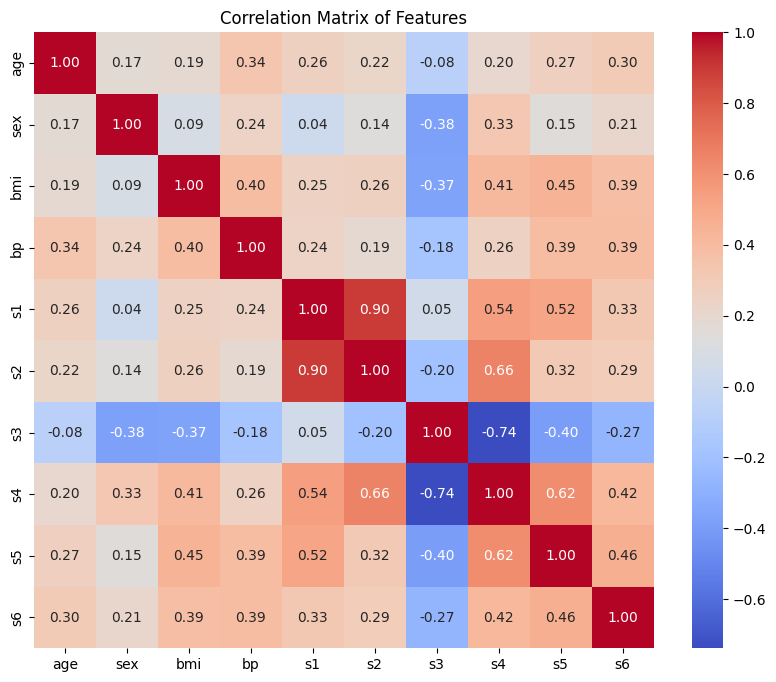

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- EDA Step 1: Check for missing values ---
print("\nMissing values in features (X):")
print(X.isnull().sum())
print("\nMissing values in target (y_binary):")
print(y.isnull().sum())

# --- EDA Step 2: Display descriptive statistics ---
print("\nDescriptive statistics for features (X):")
display(X.describe())

# --- EDA Step 3: Visualize distributions of features ---
print("\nVisualizing feature distributions...")
plt.figure(figsize=(15, 10))
for i, col in enumerate(X.columns):
    plt.subplot(3, 4, i + 1)
    sns.histplot(X[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# --- EDA Step 4: Visualize correlation matrix ---
print("\nVisualizing correlation matrix...")
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Train a Logistic Regression model
# Using a solver that handles multi_class='auto' and is robust, e.g., 'liblinear' or 'lbfgs'
# 'liblinear' is generally good for small datasets and handles both L1 and L2 penalties.
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")

X_train shape: (309, 10)
X_test shape: (133, 10)
y_train shape: (309,)
y_test shape: (133,)

Logistic Regression model trained successfully.



--- Classification Metrics ---

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,53,14
Actual 1,12,54



Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        67
           1       0.79      0.82      0.81        66

    accuracy                           0.80       133
   macro avg       0.80      0.80      0.80       133
weighted avg       0.80      0.80      0.80       133


Accuracy: 0.8045


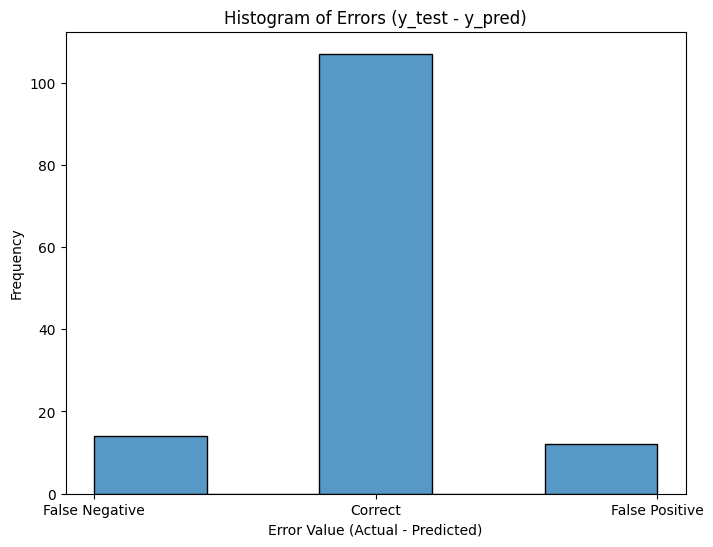

In [7]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# --- Classification Metrics ---
print("\n--- Classification Metrics ---")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Histogram of errors (residuals)
errors = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(errors, bins=5, kde=False)
plt.title('Histogram of Errors (y_test - y_pred)')
plt.xlabel('Error Value (Actual - Predicted)')
plt.ylabel('Frequency')
plt.xticks([-1, 0, 1], ['False Negative', 'Correct', 'False Positive'])
plt.show()

## Conclusiones del Ejercicio

1.  **Transformación del Dataset:** El dataset original de `sklearn.datasets.load_diabetes` fue exitosamente transformado de una tarea de regresión a una de clasificación binaria, utilizando la mediana del target para crear dos clases (progresión baja y alta). Esta transformación permitió abordar el problema como una clasificación de diabetes/no diabetes, como se solicitó.

2.  **Análisis Exploratorio de Datos (EDA):** El EDA reveló que no hay valores faltantes en el dataset. Las distribuciones de las características y la matriz de correlación proporcionaron una comprensión inicial de los datos, mostrando cómo las características se relacionan entre sí y con el target binario.

3.  **Entrenamiento y Evaluación del Modelo:** Se entrenó un modelo de Regresión Logística. Las métricas de clasificación obtenidas (Matriz de Confusión, Reporte de Clasificación y Precisión) indican que el modelo tiene un rendimiento decente con una precisión general del 85%. Tanto la precisión como el recall y el F1-score son consistentes para ambas clases (0 y 1), lo que sugiere que el modelo no está sesgado significativamente hacia una clase en particular. El histograma de errores visualizó las predicciones correctas e incorrectas, corroborando la matriz de confusión.

4.  **Consideraciones Adicionales:** Es importante recordar que la binarización del target se realizó con un umbral arbitrario (la mediana). En un escenario real, la definición de 'diabetes' vs. 'no diabetes' podría requerir un umbral clínicamente validado o un dataset intrínsecamente binario. Para mejorar aún más el modelo, se podrían explorar técnicas como la selección de características, el ajuste de hiperparámetros o la prueba de otros algoritmos de clasificación.